# Paper Data Figure

One-row figure illustrating the diversity of data types handled by the model:

1. **NTU RGB+D skeleton** — human motion as a temporal sequence of joint positions
2. **QM9 molecule** — 3D molecular structure
3. **$L^2([0,1];\mathbb{R}^2)$ functions** — functional / trajectory data
4. **Scalar field on $S^2$** — function defined on a Riemannian manifold
5. **$L^2([0,1]^2;\mathbb{R})$ surface** — 2D spatial field
6. **$\mathrm{SO}(3)$ rotations** — orientation data on a Lie group

Run the cells in order.  The final cell creates `fig` which you can save or tweak.

In [1]:
import os, sys, glob, random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from scipy.special import sph_harm

project_root = os.path.abspath("")
if not os.path.exists(os.path.join(project_root, "src")):
    project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

from src import (
    generate_l2_2d_gaussian_data,
    generate_so3_mixture_data,
)
from examples.train_l2_gaussian import generate_l2_gaussian_data
from examples.visualize_ntu_skeleton import (
    parse_skeleton_file, plot_skeleton_frame, BONES, BONE_GROUPS, GROUP_COLORS,
)
from examples.train_ntu_skeleton import (
    skeleton_to_trajectory, resample_trajectory, trajectory_to_joints,
)

device = torch.device("cpu")
dtype  = torch.float64

FIG_DIR = os.path.join(project_root, "paper", "images")
os.makedirs(FIG_DIR, exist_ok=True)

# ── shared style helpers ──────────────────────────────────────────────────────
SHOW_3D_FRAME = False   # set False to hide the grey background box on 3-D plots

def clean_3d(ax, *, hide_grid=True):
    """Remove tick labels and optionally the grid from a 3-D axis."""
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    if hide_grid:
        ax.grid(False)
    edge_color = "#dddddd" if SHOW_3D_FRAME else "none"
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor(edge_color)
    if not SHOW_3D_FRAME:
        ax.xaxis.line.set_color("none")
        ax.yaxis.line.set_color("none")
        ax.zaxis.line.set_color("none")


def set_equal_3d(ax, pts):
    """Force equal aspect ratio for a 3-D scatter/line plot."""
    mins = pts.min(0); maxs = pts.max(0)
    c = 0.5 * (mins + maxs)
    r = 0.55 * max(maxs - mins + 1e-8)
    ax.set_xlim(c[0]-r, c[0]+r)
    ax.set_ylim(c[1]-r, c[1]+r)
    ax.set_zlim(c[2]-r, c[2]+r)


print("imports OK")

/home/dani/projects/mixture/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


imports OK


## 1  NTU RGB+D skeleton

In [2]:
random.seed(42); np.random.seed(42)

DATA_ROOT  = Path(project_root) / "data" / "ntu_rgbd_skeleton"
NTU_FILES  = sorted(glob.glob(str(DATA_ROOT / "**/*.skeleton"), recursive=True))
print(f"Found {len(NTU_FILES)} skeleton files")

GRID_NTU   = 64      # resampled length

# ── pick one file and load ────────────────────────────────────────────────────
ntu_path   = random.choice(NTU_FILES)
ntu_frames = parse_skeleton_file(ntu_path)
ntu_traj   = resample_trajectory(skeleton_to_trajectory(ntu_frames), GRID_NTU)
ntu_joints = trajectory_to_joints(ntu_traj)  # (GRID_NTU, 25, 3)

# centre once by the time-mean of the hip joint (joint 0)
# identical to the other notebook's X_centered + mean_traj convention
hip_mean       = ntu_joints[:, 0, :].mean(axis=0)          # (3,)
joints_display = ntu_joints - hip_mean[None, None, :]       # (GRID_NTU, 25, 3)

print(f"Loaded: {Path(ntu_path).name}  →  joints shape {joints_display.shape}")

Found 114480 skeleton files
Loaded: S026C003P070R001A111.skeleton  →  joints shape (64, 25, 3)


## 2  QM9 molecule

In [3]:
from atomic_datasets import datasets as atomic_ds_module

ATOM_COLORS = {"H": "#B8B8B8", "C": "#2C2C2C", "N": "#2B5DB1",
               "O": "#D84A4A", "F": "#2BA84A"}
ATOM_RADII  = {"H": 0.31, "C": 0.76, "N": 0.71, "O": 0.66, "F": 0.57}
ATOM_SIZES  = {"H": 40,  "C": 100, "N": 105, "O": 110, "F": 90}

atomic_root = Path(project_root) / "data" / "atomic_datasets"
qm9_dataset = atomic_ds_module.QM9(root_dir=str(atomic_root), split="train")

# pick a molecule with a medium number of heavy atoms (~10–14)
np.random.seed(7)
mol_idx = int(np.random.randint(200, 1000))
mol = qm9_dataset[mol_idx]
mol_pos   = np.array(mol["nodes"]["positions"])
mol_types = list(mol["nodes"]["atom_types"])
print(f"Molecule {mol_idx}: {len(mol_types)} atoms  {mol_types}")

def atomic_bonds(positions, atom_types, slack=0.25, scale=1.15):
    bonds = []
    for i in range(len(positions)):
        for j in range(i+1, len(positions)):
            ri = ATOM_RADII.get(str(atom_types[i]), 0.8)
            rj = ATOM_RADII.get(str(atom_types[j]), 0.8)
            if np.linalg.norm(positions[i] - positions[j]) <= scale*(ri+rj)+slack:
                bonds.append((i, j))
    return bonds

def canonicalize(pts):
    pts = pts - pts.mean(0)
    if len(pts) >= 3:
        _, _, vh = np.linalg.svd(pts, full_matrices=False)
        pts = pts @ vh.T
    return pts

Loading QM9 from cache: /home/dani/projects/mixture/data/atomic_datasets/qm9/qm9_preprocessed_False.npz
Loaded 133885 molecules from cache
Dataset description available at: /home/dani/projects/mixture/data/atomic_datasets/qm9/QM9_README
Molecule 375: 14 atoms  ['C', 'N', 'C', 'C', 'C', 'N', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']


## 3  $L^2([0,1];\mathbb{R}^2)$ functional data

In [4]:
torch.manual_seed(42)

n_l2   = 120
K_l2   = 4
grid   = 80
R_l2   = 12
d_l2   = 2
pi_l2  = torch.tensor([0.35, 0.28, 0.22, 0.15], dtype=dtype)

X_raw_l2, X_coeffs_l2, assign_l2, info_l2 = generate_l2_gaussian_data(
    n_samples=n_l2, n_components=K_l2, grid_size=grid,
    R=R_l2, T=1.0, d=d_l2, component_weights=pi_l2,
    seed=7, device=device, dtype=dtype,
)

t_l2     = info_l2["t"].numpy()          # (grid,)
X_np_l2  = X_raw_l2.numpy()             # (n_l2, grid, d_l2)
asgn_l2  = assign_l2.numpy()
print(f"L^2 data: {X_np_l2.shape}")

L^2 data: (120, 80, 2)


## 4  Scalar field on $S^2$

In [5]:
np.random.seed(99)   # seed for a vivid field

# ── real spherical harmonics Y_l^m ───────────────────────────────────────────
def real_Ylm(l, m, theta, phi):
    """theta in [0,pi], phi in [0,2pi] (physics convention)."""
    if m > 0:
        return np.sqrt(2) * (-1)**m * sph_harm(m,  l, phi, theta).real
    elif m == 0:
        return sph_harm(0, l, phi, theta).real
    else:
        return np.sqrt(2) * (-1)**m * sph_harm(-m, l, phi, theta).imag

# ── spherical grid ────────────────────────────────────────────────────────────
n_phi, n_the = 180, 90
phi_   = np.linspace(0, 2*np.pi, n_phi)
theta_ = np.linspace(0,   np.pi, n_the)
PHI, THE = np.meshgrid(phi_, theta_)

Xs2 = np.sin(THE) * np.cos(PHI)
Ys2 = np.sin(THE) * np.sin(PHI)
Zs2 = np.cos(THE)

# ── scalar field as stream function (higher L_max → sharper features) ─────────
L_max_s2 = 8
field_s2 = np.zeros_like(Xs2)
for l in range(1, L_max_s2 + 1):
    for m in range(-l, l + 1):
        c = np.random.randn() / np.sqrt(l + 0.3)   # mild decay
        field_s2 += c * real_Ylm(l, m, THE, PHI)
field_s2 /= np.max(np.abs(field_s2))              # normalise to [-1, 1]

# ── divergence-free tangent vector field from stream function ψ = field_s2 ────
# u_θ = −∂ψ/∂φ / sin θ  (east component),  u_φ = ∂ψ/∂θ (north component)
dtheta_step = theta_[1] - theta_[0]
dphi_step   = phi_[1]   - phi_[0]

dpsi_dtheta = np.gradient(field_s2, dtheta_step, axis=0)
dpsi_dphi   = np.gradient(field_s2, dphi_step,   axis=1)

sin_THE = np.sin(THE);  cos_THE = np.cos(THE)
cos_PHI = np.cos(PHI);  sin_PHI = np.sin(PHI)
safe_sin = np.where(sin_THE < 0.10, 0.10, sin_THE)

u_theta = -dpsi_dphi   / safe_sin
u_phi   =  dpsi_dtheta

# convert to Cartesian
Ux = u_theta * cos_THE * cos_PHI - u_phi * sin_PHI
Uy = u_theta * cos_THE * sin_PHI + u_phi * cos_PHI
Uz = u_theta * (-sin_THE)

# ── subsample arrows ─────────────────────────────────────────────────────────
ARROW_LEN = 0.11
step_phi, step_the = 12, 6
pole_mask = sin_THE > 0.22

q_mask = np.zeros_like(field_s2, dtype=bool)
q_mask[::step_the, ::step_phi] = True
q_mask &= pole_mask

arrow_mag = np.sqrt(Ux**2 + Uy**2 + Uz**2) + 1e-12
q_x = Xs2[q_mask];  q_y = Ys2[q_mask];  q_z = Zs2[q_mask]
q_u = (Ux / arrow_mag * ARROW_LEN)[q_mask]
q_v = (Uy / arrow_mag * ARROW_LEN)[q_mask]
q_w = (Uz / arrow_mag * ARROW_LEN)[q_mask]

print(f"S^2 field: L_max={L_max_s2}, {q_x.shape[0]} arrows")

S^2 field: L_max=8, 180 arrows


## 5  $L^2([0,1]^2;\mathbb{R})$ surface

In [6]:
torch.manual_seed(42)

n_2d   = 60
K_2d   = 3
Rs = Rt = 7
pi_2d  = torch.tensor([0.45, 0.35, 0.20], dtype=dtype)

X_raw_2d, X_coeffs_2d, assign_2d, info_2d = generate_l2_2d_gaussian_data(
    n_samples=n_2d, n_components=K_2d,
    grid_size_s=28, grid_size_t=28, R_s=Rs, R_t=Rt,
    T=1.0, S=1.0, d=1, component_weights=pi_2d,
    seed=42, device=device, dtype=dtype,
)

Sgrid_2d = info_2d["s_grid"].numpy()   # (gs, gt)
Tgrid_2d = info_2d["t_grid"].numpy()   # (gs, gt)
X_np_2d  = X_raw_2d.numpy()            # (n_2d, gs, gt, 1)
asgn_2d  = assign_2d.numpy()
print(f"2D data: {X_np_2d.shape}")

2D data: (60, 28, 28, 1)


## 6  SO(3) rotation data

In [7]:
torch.manual_seed(42)

n_so3   = 150
K_so3   = 3

X_euler, assign_so3, info_so3 = generate_so3_mixture_data(
    n_samples=n_so3, n_components=K_so3, noise_concentration=35.0,
    seed=7, device=device, dtype=dtype,
)

def euler_to_R(alpha, beta, gamma):
    ca, sa = np.cos(alpha), np.sin(alpha)
    cb, sb = np.cos(beta),  np.sin(beta)
    cg, sg = np.cos(gamma), np.sin(gamma)
    return np.array([
        [ca*cb*cg - sa*sg, -ca*cb*sg - sa*cg,  ca*sb],
        [sa*cb*cg + ca*sg, -sa*cb*sg + ca*cg,  sa*sb],
        [       -sb*cg,           sb*sg,           cb],
    ])

ref_dir = np.array([1.0, 0.0, 0.0])
sphere_pts = np.stack([
    euler_to_R(*row) @ ref_dir for row in X_euler.numpy()
])  # (n_so3, 3)

asgn_so3 = assign_so3.numpy()
true_dirs_so3 = np.stack([
    euler_to_R(*row) @ ref_dir for row in info_so3["mean_rotations"].numpy()
])  # (K, 3)

print(f"SO(3) data: {sphere_pts.shape}")

SO(3) data: (150, 3)


## 7  CGM hourly glucose (all-patient average) — for col 3

In [8]:
from examples.train_glucodensity_temporal import load_and_preprocess_cgm, compute_sliding_windows

_cgm_csv = os.path.join(project_root, "data/glucodensities/cgm_all_patients.csv")
_cgm_patient_data = load_and_preprocess_cgm(_cgm_csv, max_prop_missing=0.20, block_size=4, verbose=False)

_cgm_curves, _cgm_t_indices, _, _, _ = compute_sliding_windows(
    _cgm_patient_data, window_size=4, stride=1, verbose=False
)
_cgm_hourly_all = _cgm_curves.reshape(_cgm_curves.shape[0], 24, 12).mean(axis=2)
_cgm_weeks      = _cgm_t_indices / 7.0

_n_bins_cgm  = 15
_edges_cgm   = np.linspace(_cgm_weeks.min(), _cgm_weeks.max() + 0.01, _n_bins_cgm + 1)
cgm_hours    = np.arange(24)
cgm_surf     = np.array([
    _cgm_hourly_all[(_cgm_weeks >= _edges_cgm[i]) & (_cgm_weeks < _edges_cgm[i + 1])].mean(0)
    for i in range(_n_bins_cgm)
])
print(f"CGM surface: {cgm_surf.shape}  (week-bins × hours)")

/home/dani/projects/mixture/examples/train_glucodensity_temporal.py:181: RuntimeWarning: Mean of empty slice
  avg_curve = np.nanmean(window, axis=0)  # (288,)


CGM surface: (15, 24)  (week-bins × hours)


## 8  Sym(10) — symmetric matrix sample — for col 7

In [9]:
np.random.seed(37)
_B10     = np.random.randn(10, 15)
_C10     = _B10 @ _B10.T
_d10     = np.sqrt(np.diag(_C10))
sym10_mat = _C10 / np.outer(_d10, _d10)   # correlation matrix, values in [-1, 1]
print(f"Sym(10): {sym10_mat.shape}, min={sym10_mat.min():.2f}, max={sym10_mat.max():.2f}")

Sym(10): (10, 10), min=-0.68, max=1.00


## Main figure — 1 row, 6 columns

Adjust `figsize`, `elev`/`azim` angles, colour maps, titles and `n_snaps` freely.

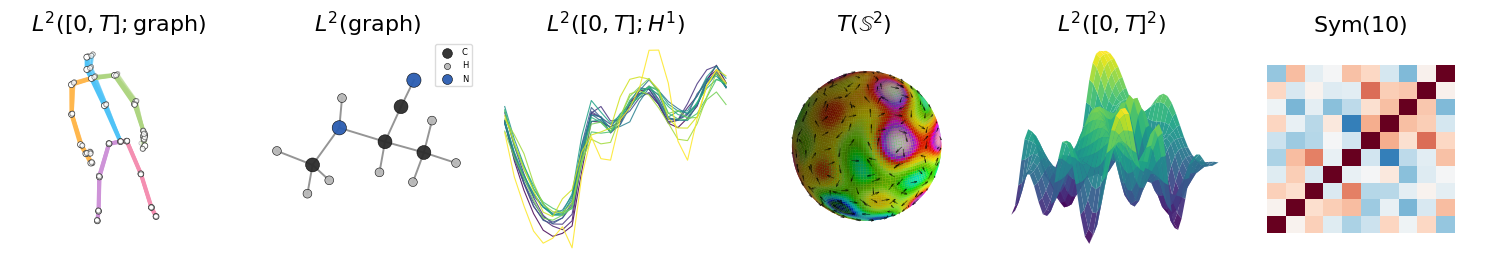

Saved → /home/dani/projects/mixture/paper/images/data_overview.pdf


In [48]:
# ── global view & layout ──────────────────────────────────────────────────────
FH     = 2.5
ELEV, AZIM = 20, -50    # shared 3-D camera angle for all subplots
FONT_SIZE = 16

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6*FH, FH), facecolor="white")
gs  = GridSpec(1, 6, figure=fig,
               wspace=0.02, left=0.005, right=0.995,
               top=0.91, bottom=0.04)

# ─────────────────────────────────────────────────────────────────────────────
# COL 1 — NTU skeleton  (temporal graph)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], projection="3d", facecolor="white")

snaps = np.linspace(0, GRID_NTU - 1, 6, dtype=int)
for si, fidx in enumerate(snaps):
    t_frac = si / max(len(snaps) - 1, 1)
    plot_skeleton_frame(
        ax1, joints_display[fidx],
        alpha=0.2 + 0.8 * t_frac,
        linewidth=1.0 + 2.0 * t_frac,
        joint_size=6 + 12 * t_frac,
    )

set_equal_3d(ax1, joints_display.reshape(-1, 3))
clean_3d(ax1)
ax1.view_init(elev=ELEV, azim=AZIM)
ax1.set_title("$L^2([0,T]; \\mathrm{graph})$", fontsize=FONT_SIZE)

# ─────────────────────────────────────────────────────────────────────────────
# COL 2 — QM9 molecule  (graph)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], projection="3d", facecolor="white")

mol_pos_can = canonicalize(mol_pos)
for i, j in atomic_bonds(mol_pos_can, mol_types):
    ax2.plot(
        [mol_pos_can[i, 0], mol_pos_can[j, 0]],
        [mol_pos_can[i, 1], mol_pos_can[j, 1]],
        [mol_pos_can[i, 2], mol_pos_can[j, 2]],
        color="#8a8a8a", lw=1.4, alpha=0.9,
    )
for atom in sorted(set(mol_types)):
    mask = np.array(mol_types) == atom
    ax2.scatter(
        mol_pos_can[mask, 0], mol_pos_can[mask, 1], mol_pos_can[mask, 2],
        s=ATOM_SIZES.get(str(atom), 80),
        c=ATOM_COLORS.get(str(atom), "#cccccc"),
        edgecolors="black", linewidths=0.4, alpha=0.95, label=str(atom),
    )

set_equal_3d(ax2, mol_pos_can)
clean_3d(ax2)
ax2.view_init(ELEV+20, azim=AZIM-70)
ax2.set_title("$L^2(\\mathrm{graph})$", fontsize=FONT_SIZE)
ax2.legend(loc="upper right", fontsize=6, framealpha=0.7, markerscale=0.7)

# ─────────────────────────────────────────────────────────────────────────────
# COL 3 — CGM hourly glucose: all-patient average, colored by week
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

_cmap_cgm = plt.cm.viridis
for i in range(cgm_surf.shape[0]):
    color = _cmap_cgm(i / max(1, cgm_surf.shape[0] - 1))
    ax3.plot(cgm_hours, cgm_surf[i, :], color=color, alpha=0.85, lw=0.8)

ax3.axis("off")
ax3.set_title("$L^2([0,T]; H^1)$", fontsize=FONT_SIZE)

# ─────────────────────────────────────────────────────────────────────────────
# COL 4 — scalar field on S²  (L²(S²))
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[0, 3], projection="3d", facecolor="white")

norm_s2       = Normalize(vmin=field_s2.min(), vmax=field_s2.max())
facecolors_s2 = plt.cm.gist_ncar(norm_s2(field_s2))

ax4.plot_surface(
    Xs2, Ys2, Zs2,
    facecolors=facecolors_s2,
    rstride=1, cstride=1,
    linewidth=0, antialiased=True, alpha=0.97,
)
ax4.quiver(
    q_x, q_y, q_z,
    q_u, q_v, q_w,
    color="k", alpha=0.60, linewidth=0.55,
    arrow_length_ratio=0.45,
)

clean_3d(ax4)
ax4.set_box_aspect([1, 1, 1])
ax4.view_init(elev=ELEV, azim=AZIM)
ax4.set_title("$T(\\mathbb{S}^2)$", fontsize=FONT_SIZE)

# ─────────────────────────────────────────────────────────────────────────────
# COL 5 — L²([0,T]²; ℝ) — single surface
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[0, 4], projection="3d", facecolor="white")

idx_surf = np.where(asgn_2d == 0)[0][0]
Zsurf    = X_np_2d[idx_surf, :, :, 0]
ax5.plot_surface(
    Sgrid_2d, Tgrid_2d, Zsurf,
    cmap=plt.cm.viridis,
    linewidth=0, antialiased=True, alpha=0.95,
)

clean_3d(ax5)
ax5.view_init(elev=ELEV, azim=AZIM)
ax5.set_title("$L^2([0,T]^2)$", fontsize=FONT_SIZE)

# ─────────────────────────────────────────────────────────────────────────────
# COL 6 — SO(3): 1 sample shown on S²
# ─────────────────────────────────────────────────────────────────────────────
# ax6 = fig.add_subplot(gs[0, 5], projection="3d", facecolor="white")

# u   = np.linspace(0, 2*np.pi, 40)
# v   = np.linspace(0, np.pi,   20)
# ax6.plot_surface(
#     np.outer(np.cos(u), np.sin(v)),
#     np.outer(np.sin(u), np.sin(v)),
#     np.outer(np.ones_like(u), np.cos(v)),
#     alpha=0.06, color="gray", linewidth=0,
# )

# ax6.scatter(
#     sphere_pts[0, 0], sphere_pts[0, 1], sphere_pts[0, 2],
#     s=80, color=plt.cm.tab10(0.0),
#     edgecolors="black", linewidths=0.8, zorder=5,
# )

# ax6.set_box_aspect([1, 1, 1])
# clean_3d(ax6)
# ax6.view_init(elev=ELEV, azim=AZIM)
# ax6.set_title("$L^2(\\mathrm{SO}(3))$", fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# COL 7 — Sym(10): symmetric matrix heatmap
# ─────────────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[0, 5])

ax7.imshow(sym10_mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto", origin="lower")
ax7.set_xticks([]); ax7.set_yticks([])
ax7.set_title("$\\mathrm{Sym}(10)$", fontsize=FONT_SIZE)

for ax in (ax4, ax5):
    ax.margins(0, 0, 0)                  # remove autoscale padding
    ax.set_box_aspect((1, 1, 1), zoom=1.2)
ax1.set_box_aspect((1, 1, 1), zoom=1)   # for the 2-D surface
ax2.set_box_aspect((1, 1, 1), zoom=1)   # for the 2-D surface

ax7.use_sticky_edges = False   # needed for images / imshow
ax7.margins(x=0.15, y=0.15)    # increase inner padding
ax7.autoscale_view()
ax7.axis('off')

# ─────────────────────────────────────────────────────────────────────────────
# save
# ─────────────────────────────────────────────────────────────────────────────
out_pdf = os.path.join(FIG_DIR, "data_overview.pdf")
# out_png = os.path.join(FIG_DIR, "data_overview.png")
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=150)
# fig.savefig(out_png, format="png", bbox_inches="tight", dpi=200)
plt.show()
print(f"Saved → {out_pdf}")

## Tweaks — individual panel extras

Run any of the cells below independently to regenerate a single panel.

In [33]:
def set_equal_3d(ax, pts):
    """Force equal aspect ratio for a 3-D scatter/line plot."""
    mins = pts.min(0); maxs = pts.max(0)
    c = 0.5 * (mins + maxs)
    r = 0.35 * max(maxs - mins + 1e-8)
    ax.set_xlim(c[0]-r, c[0]+r)
    ax.set_ylim(c[1]-r, c[1]+r)
    ax.set_zlim(c[2]-r, c[2]+r)

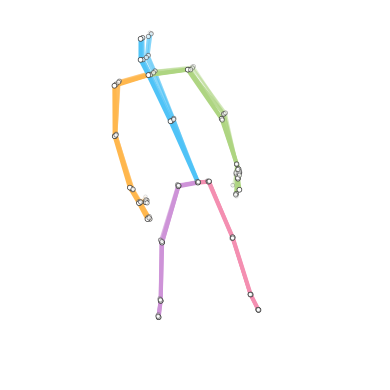

In [34]:
ntu_frames = parse_skeleton_file(NTU_FILES[98])
ntu_traj   = resample_trajectory(skeleton_to_trajectory(ntu_frames), GRID_NTU)
ntu_joints = trajectory_to_joints(ntu_traj)  # (GRID_NTU, 25, 3)

# hip_mean       = ntu_joints[:, 0, :].mean(axis=0)          # (3,)
# joints_display = ntu_joints - hip_mean[None, None, :]       # (GRID_NTU, 25, 3)

# ── standalone NTU panel ─────────────────────────────────────────────────────
fig_ntu, ax_ntu = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={"projection": "3d"})
snaps_ = np.linspace(0, GRID_NTU - 1, 6, dtype=int)
for si, fidx in enumerate(snaps_):
    t_frac = si / max(len(snaps_) - 1, 1)
    plot_skeleton_frame(ax_ntu, joints_display[fidx],
                        alpha=0.2 + 0.8 * t_frac,
                        linewidth=1.0 + 2.0 * t_frac,
                        joint_size=6 + 6 * t_frac)
set_equal_3d(ax_ntu, joints_display.reshape(-1, 3))
clean_3d(ax_ntu)
ax_ntu.view_init(elev=20, azim=-50)
ax_ntu.set_box_aspect((1, 1, 1), zoom=1.) 
plt.tight_layout()
plt.show()

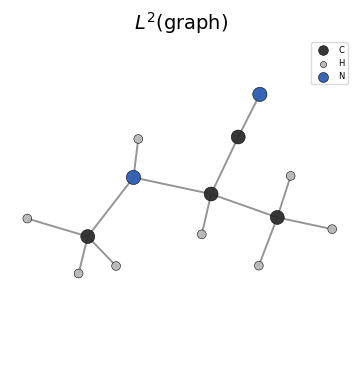

In [46]:
fig_s2, ax2 = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={"projection": "3d"})
#ax2 = fig.add_subplot(gs[0, 1], projection="3d", facecolor="white")

mol_pos_can = canonicalize(mol_pos)
for i, j in atomic_bonds(mol_pos_can, mol_types):
    ax2.plot(
        [mol_pos_can[i, 0], mol_pos_can[j, 0]],
        [mol_pos_can[i, 1], mol_pos_can[j, 1]],
        [mol_pos_can[i, 2], mol_pos_can[j, 2]],
        color="#8a8a8a", lw=1.4, alpha=0.9,
    )
for atom in sorted(set(mol_types)):
    mask = np.array(mol_types) == atom
    ax2.scatter(
        mol_pos_can[mask, 0], mol_pos_can[mask, 1], mol_pos_can[mask, 2],
        s=ATOM_SIZES.get(str(atom), 80),
        c=ATOM_COLORS.get(str(atom), "#cccccc"),
        edgecolors="black", linewidths=0.4, alpha=0.95, label=str(atom),
    )

set_equal_3d(ax2, mol_pos_can)
clean_3d(ax2)
ax2.view_init(elev=ELEV+20, azim=AZIM-70)
ax2.set_title("$L^2(\\mathrm{graph})$", fontsize=FONT_SIZE)
ax2.legend(loc="upper right", fontsize=6, framealpha=0.7, markerscale=0.7)
plt.tight_layout()
plt.show()

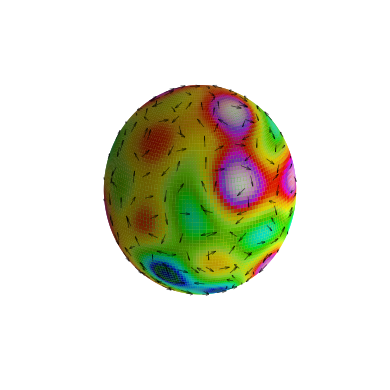

In [ ]:
# ── standalone S^2 field panel ───────────────────────────────────────────────
fig_s2, ax_s2 = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={"projection": "3d"})
norm_ = Normalize(vmin=field_s2.min(), vmax=field_s2.max())
ax_s2.plot_surface(Xs2, Ys2, Zs2,
                   facecolors=plt.cm.gist_ncar(norm_(field_s2)),
                   rstride=1, cstride=1, linewidth=0, antialiased=True, alpha=0.97)
ax_s2.quiver(q_x, q_y, q_z, q_u, q_v, q_w,
             color="k", alpha=0.60, linewidth=0.55, arrow_length_ratio=0.45)
clean_3d(ax_s2)
ax_s2.set_box_aspect([1, 1, 1])
ax_s2.view_init(elev=20, azim=-50)
plt.tight_layout()
plt.show()